#TRAINING THE MODEL

In [ ]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# LOAD LABELS AND OPTIONAL METADATA
# Load the main labels file
!cp -r "/content/drive/MyDrive/ENGG 680/HAM10000/prepared_images" /content/
!cp "/content/drive/MyDrive/ENGG 680/HAM10000/prepared_images_labels.csv" /content/


In [ ]:
labels_df = pd.read_csv( "/content/prepared_images_labels.csv")  # Change path if needed


In [ ]:
# Change string lesion labels into integers

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
labels_df['label_int'] = le.fit_transform(labels_df['label'])   # 'label' is the string column
num_classes = labels_df['label_int'].nunique()


In [ ]:
# === 2. DEFINE PYTORCH DATASET CLASS ===
class SkinLesionDataset(Dataset):
    """
    Custom dataset that loads images (and optionally, metadata features for multimodal) from dataframe.
    Adjust __getitem__ to add metadata if needed.
    """
    def __init__(self, df, img_dir, transform=None):
        self.df = df
        self.img_dir = img_dir
        self.transform = transform
        # self.use_metadata = False

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Path to image
        img_name = os.path.join(self.img_dir, self.df.iloc[idx]['image_path'])
        image = Image.open(img_name).convert('RGB')  # Ensure 3 channels

        # Image transforms (incl. normalization & augmentation if train)
        if self.transform:
            image = self.transform(image)

        # Load label as integer (change column if needed)
        label = int(self.df.iloc[idx]['label_int'])

        # Example for adding metadata (uncomment if using multimodal)
        # if self.use_metadata:
        #     meta_features = torch.tensor(self.df.iloc[idx][['age', 'sex_encoded', ...]].values, dtype=torch.float32)
        #     return image, meta_features, label
        # else:
        return image, label

In [ ]:
# labels_df is your full dataframe, 'label_int' is the encoded label column

print("Class counts (full dataset):")
print(labels_df['label_int'].value_counts())

print("\nClass proportions (full dataset):")
print(labels_df['label_int'].value_counts(normalize=True))


Class counts (full dataset):
label_int
5    6705
4    1113
2    1099
1     514
0     327
6     142
3     115
Name: count, dtype: int64

Class proportions (full dataset):
label_int
5    0.669496
4    0.111133
2    0.109735
1    0.051323
0    0.032651
6    0.014179
3    0.011483
Name: proportion, dtype: float64


In [ ]:
from sklearn.model_selection import train_test_split

# Use 100% of the dataset
subset_df = labels_df  # No subsetting

print("Full dataset size:", len(labels_df))
print("Subset (100%) size:", len(subset_df))
print("Class distribution in subset:")
print(subset_df['label_int'].value_counts(normalize=True))


Full dataset size: 10015
Subset (100%) size: 10015
Class distribution in subset:
label_int
5    0.669496
4    0.111133
2    0.109735
1    0.051323
0    0.032651
6    0.014179
3    0.011483
Name: proportion, dtype: float64


In [ ]:
# 2) Now split this subset into train/test
train_df, test_df = train_test_split(
    subset_df,
    test_size=0.15,
    stratify=subset_df['label_int'],
    random_state=42
)

# 3) Split train further into train/val if you currently do that
train_df, val_df = train_test_split(
    train_df,
    test_size=0.15,
    stratify=train_df['label_int'],
    random_state=42
)

In [ ]:
# Full dataset size
full_size = len(labels_df)

# Sizes after subsetting and splitting
subset_size = len(subset_df)
train_size  = len(train_df)
val_size    = len(val_df)
test_size   = len(test_df)

print("Full dataset size:", full_size)
print("Train size:", train_size)
print("Val size:", val_size)
print("Test size:", test_size)


# Check that train+val+test equals full
split_total = train_size + val_size + test_size
print("Train+Val+Test total:", split_total)



Full dataset size: 10015
Train size: 7235
Val size: 1277
Test size: 1503
Train+Val+Test total: 10015


In [ ]:
# === 4. SET UP IMAGE TRANSFORMS ===
# Training uses realistic augmentation for dermoscopy images
data_transforms = {
    'train': transforms.Compose([
        # Start from a slightly random crop near full size, then resize to 224x224
        transforms.RandomResizedCrop(
            size=224,
            scale=(0.9, 1.1),    # small zoom in/out
            ratio=(0.9, 1.1)     # slight aspect ratio variation
        ),
        transforms.RandomHorizontalFlip(p=0.5),          # flip left/right
        transforms.RandomRotation(degrees=15),           # small rotation
        transforms.ColorJitter(
            brightness=0.1,       # ±10% brightness
            contrast=0.1          # ±10% contrast
            # leave saturation/hue unchanged to preserve color patterns
        ),
        transforms.ToTensor(),                            # to tensor [0,1]
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )  # VGG16 ImageNet means/stds
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(
            [0.485, 0.456, 0.406],
            [0.229, 0.224, 0.225]
        )
    ])
}

In [ ]:
# Create Dataset and DataLoader objects
img_dir = "/content/prepared_images"  # Change path if needed
train_dataset = SkinLesionDataset(train_df, img_dir, data_transforms['train'])
val_dataset   = SkinLesionDataset(val_df,   img_dir, data_transforms['val'])
test_dataset  = SkinLesionDataset(test_df,  img_dir, data_transforms['test'])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

In [ ]:
from torchvision.models import vgg16, VGG16_Weights

# === 5. LOAD VGG16 FOR TRANSFER LEARNING ===
# Download VGG16 pretrained on ImageNet; freeze features, replace final layer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the new weights argument instead of pretrained=True
weights = VGG16_Weights.IMAGENET1K_V1  # or VGG16_Weights.DEFAULT
model = vgg16(weights=weights)

for param in model.features.parameters():
    param.requires_grad = False  # Freeze convolutional base

# Change final classifier for your number of classes
num_classes = train_df['label_int'].nunique()  # or labels_df['label_int'].nunique()
model.classifier[6] = nn.Linear(4096, num_classes)
model = model.to(device)


In [ ]:
# === 6. LOSS, OPTIMIZER, METRICS ===
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=1e-4)  # Only train classifier layers

In [ ]:
# === 7. TRAINING AND VALIDATION LOOP WITH EARLY STOPPING ===
from copy import deepcopy

num_epochs = 15
patience = 3
best_val_acc = 0.0
epochs_without_improvement = 0

# Save best model weights
best_model_wts = deepcopy(model.state_dict())

# Initialize lists to store training and validation metrics
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []
train_f1_hist,   val_f1_hist   = [], []

for epoch in range(num_epochs):
    # --- TRAIN ---
    model.train()
    running_loss, running_corrects = 0.0, 0
    all_labels, all_preds = [], []

    for inputs, labels in tqdm(train_loader, desc=f'Training Epoch {epoch+1}'):
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc  = running_corrects.double() / len(train_dataset)
    epoch_f1   = f1_score(all_labels, all_preds, average='weighted')
    train_loss_hist.append(epoch_loss)
    train_acc_hist.append(epoch_acc)
    train_f1_hist.append(epoch_f1)

    # --- VALIDATE ---
    model.eval()
    val_running_loss, val_running_corrects = 0.0, 0
    val_labels, val_preds = [], []

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            val_labels.extend(labels.cpu().numpy())
            val_preds.extend(preds.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)
    val_acc  = val_running_corrects.double() / len(val_dataset)
    val_f1   = f1_score(val_labels, val_preds, average='weighted')
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)
    val_f1_hist.append(val_f1)

    # --- Output training progress for diagnostics ---
    print(f'Epoch {epoch+1}/{num_epochs}')
    print(f'Train loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}, f1: {epoch_f1:.4f}')
    print(f'Val   loss: {val_loss:.4f}, acc: {val_acc:.4f}, f1: {val_f1:.4f}')

    # --- EARLY STOPPING BASED ON VAL ACCURACY ---
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        epochs_without_improvement = 0
        best_model_wts = deepcopy(model.state_dict())
        print(f'  -> New best val acc: {best_val_acc:.4f}')
    else:
        epochs_without_improvement += 1
        print(f'  -> No improvement for {epochs_without_improvement} epoch(s)')
        if epochs_without_improvement >= patience:
            print('Early stopping triggered.')
            break

# Restore best model weights
model.load_state_dict(best_model_wts)


Training Epoch 1: 100%|██████████| 227/227 [00:52<00:00,  4.33it/s]


Epoch 1/15
Train loss: 0.9249, acc: 0.6803, f1: 0.6157
Val   loss: 0.7645, acc: 0.7275, f1: 0.6816
  -> New best val acc: 0.7275


Training Epoch 2: 100%|██████████| 227/227 [00:49<00:00,  4.61it/s]


Epoch 2/15
Train loss: 0.7983, acc: 0.7121, f1: 0.6771
Val   loss: 0.7645, acc: 0.7338, f1: 0.6713
  -> New best val acc: 0.7338


Training Epoch 3: 100%|██████████| 227/227 [00:49<00:00,  4.57it/s]


...

Training Epoch 14: 100%|██████████| 227/227 [00:49<00:00,  4.57it/s]


Epoch 14/15
Train loss: 0.5084, acc: 0.8135, f1: 0.8046
Val   loss: 0.6889, acc: 0.7627, f1: 0.7671
  -> No improvement for 1 epoch(s)


Training Epoch 15: 100%|██████████| 227/227 [00:51<00:00,  4.44it/s]


Epoch 15/15
Train loss: 0.5016, acc: 0.8184, f1: 0.8103
Val   loss: 0.7025, acc: 0.7901, f1: 0.7730
  -> No improvement for 2 epoch(s)


<All keys matched successfully>

In [ ]:
# this one saves the best version (epoch 11)
model.load_state_dict(best_model_wts)
save_path = "/content/drive/MyDrive/ENGG 680/HAM10000/best_vgg16_skinlesion.pth"
torch.save(model.state_dict(), save_path)
print(f"Best model saved to: {save_path}")

Best model saved to: /content/drive/MyDrive/ENGG 680/HAM10000/best_vgg16_skinlesion.pth


#EVALUATING THE MODEL

In [ ]:
import torch.nn.functional as F
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
import torch.nn.functional as F

all_labels, all_preds, all_probs = [], [], []

model.eval()
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        probs = F.softmax(outputs, dim=1)
        _, preds = torch.max(outputs, 1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

all_labels = np.array(all_labels)
all_preds = np.array(all_preds)
all_probs = np.vstack(all_probs)


In [ ]:
acc = accuracy_score(all_labels, all_preds)
f1_weighted = f1_score(all_labels, all_preds, average='weighted')
print(f"Overall Accuracy: {acc:.4f}")
print(f"Weighted F1-score: {f1_weighted:.4f}\n")


Overall Accuracy: 0.7745
Weighted F1-score: 0.7670



In [ ]:
print("Classification Report:\n")
print(classification_report(all_labels, all_preds, target_names=le.classes_))


Classification Report:

              precision    recall  f1-score   support

       akiec       0.45      0.29      0.35        49
         bcc       0.50      0.69      0.58        77
         bkl       0.55      0.51      0.53       165
          df       1.00      0.41      0.58        17
         mel       0.51      0.41      0.45       167
          nv       0.87      0.92      0.89      1006
        vasc       0.94      0.77      0.85        22

    accuracy                           0.77      1503
   macro avg       0.69      0.57      0.60      1503
weighted avg       0.77      0.77      0.77      1503



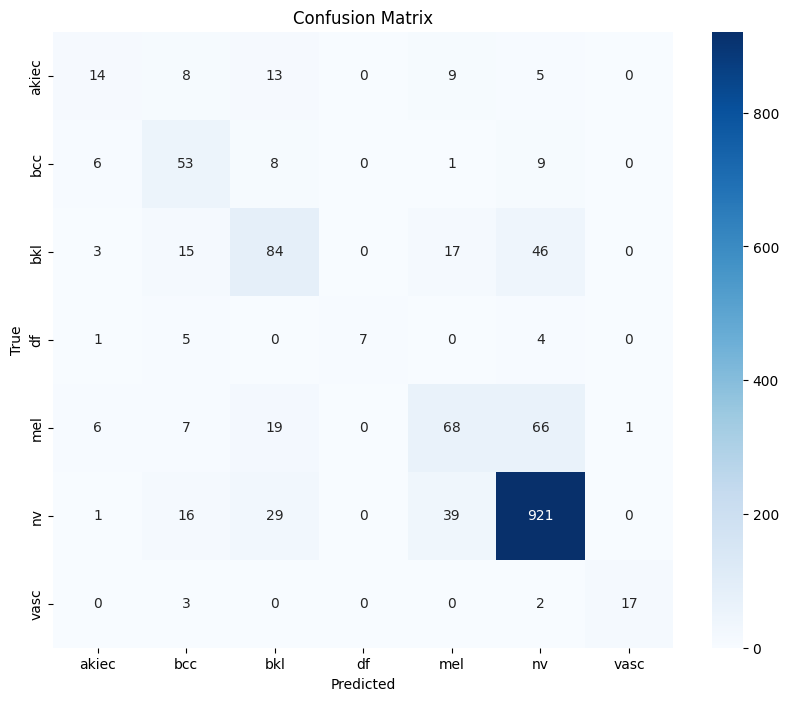

In [ ]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


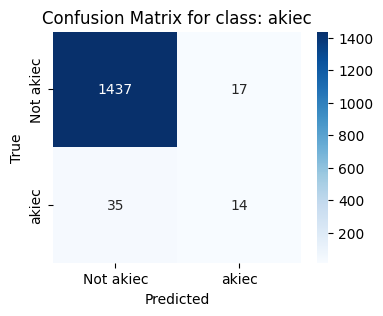

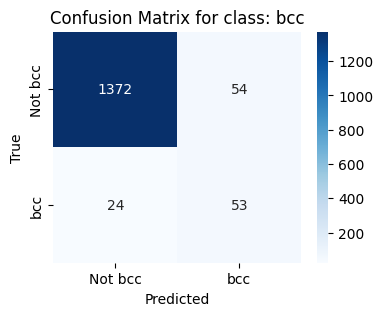

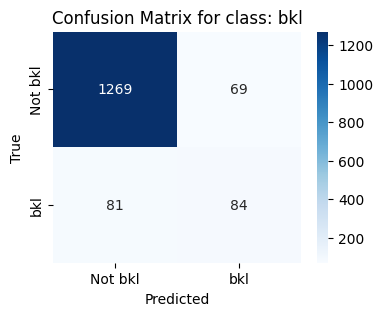

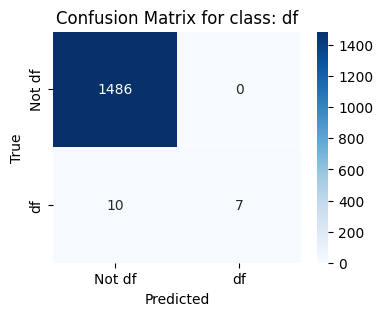

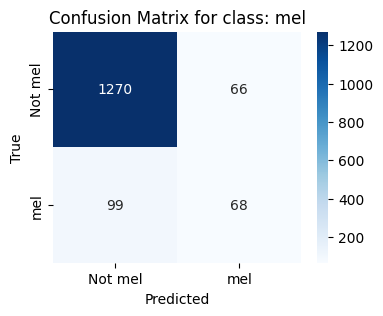

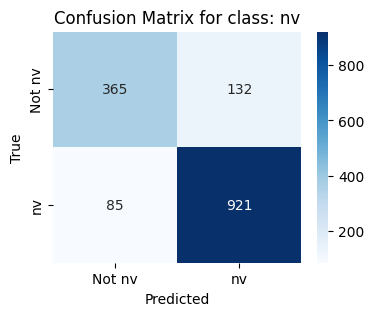

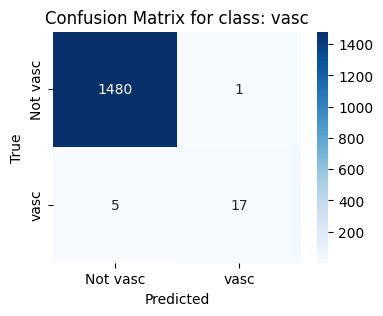

In [ ]:
# Loop over each class
for i, cls in enumerate(le.classes_):
    # One-vs-all: True = this class, False = all other classes
    true_binary = (all_labels == i).astype(int)
    pred_binary = (all_preds == i).astype(int)

    cm = confusion_matrix(true_binary, pred_binary)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=[f"Not {cls}", cls],
                yticklabels=[f"Not {cls}", cls])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(f'Confusion Matrix for class: {cls}')
    plt.show()

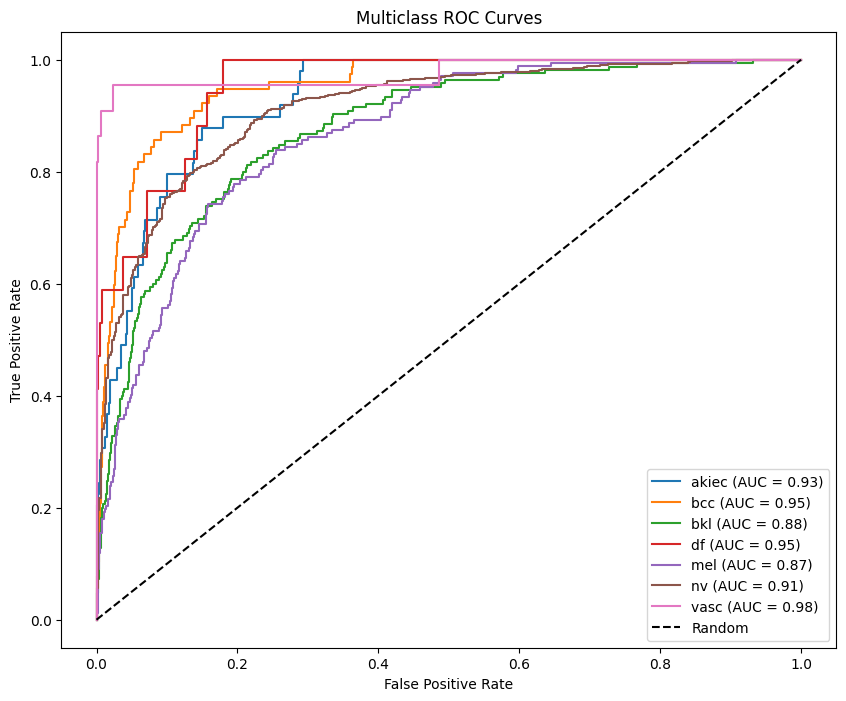

In [ ]:
y_true = label_binarize(all_labels, classes=range(len(le.classes_)))
plt.figure(figsize=(10,8))
for i, cls in enumerate(le.classes_):
    fpr, tpr, _ = roc_curve(y_true[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{cls} (AUC = {roc_auc:.2f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multiclass ROC Curves')
plt.legend()
plt.show()
